# Lab 2 - Redes Neurais

Classificador: **MLP (MultiLayer Perceptron)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lab2_utils import (
    carregar_dados, avaliar_modelo, logar_mlflow, iniciar_run,
    calibrar_threshold, predizer_com_threshold,
)

X_train, y_train, X_test, y_test = carregar_dados()

# Split de validação dentro do treino — usado para calibrar threshold
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

Iniciando servidor MLflow em background...


Servidor MLflow pronto em http://127.0.0.1:5000
Dados carregados (gerados em 2026-06-25 21:29)
  X_train: (440832, 10)  |  X_test: (64374, 10)
  Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
  Churn rate treino: 0.567  |  teste: 0.474


## MLP

Threshold calibrado: 0.3011

=== MLP ===
              precision    recall  f1-score   support

Não cancelou       0.99      0.09      0.16     33881
    Cancelou       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.41     64374
weighted avg       0.75      0.52      0.40     64374

Balanced Accuracy: 0.5421  |  Kappa: 0.0802


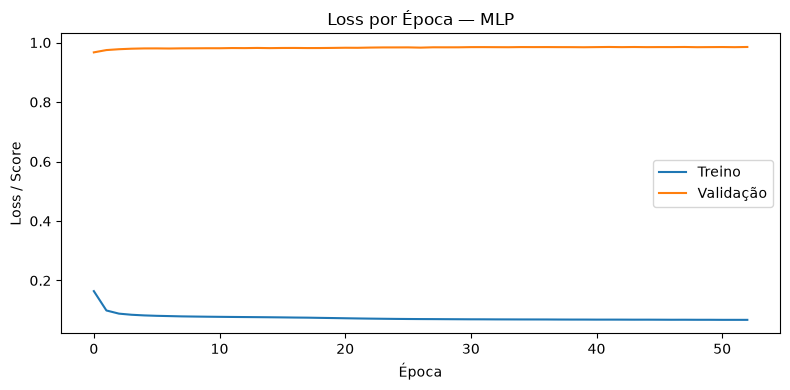

🏃 View run MLP at: http://127.0.0.1:5000/#/experiments/1/runs/7bc963ba99614c769c3ca0533fd16f89
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [2]:
# ─── MLP ──────────────────────────────────────────────────────
# Treina em X_tr (80%), calibra threshold via predict_proba no X_val (20%).
# early_stopping usa internamente 10% do X_tr como validação de parada.
from sklearn.neural_network import MLPClassifier

hidden = (64, 32)
params = {
    'modelo': 'MLP',
    'hidden_layer_sizes': str(hidden),
    'learning_rate_init': 0.001,
    'alpha': 0.01,
    'max_iter': 100,
    'activation': 'relu',
    'solver': 'adam',
    'early_stopping': True,
    'scaler': 'StandardScaler (centralizado)',
}

with iniciar_run("MLP", notebook="2B", params=params):
    model = MLPClassifier(
        hidden_layer_sizes=hidden,
        learning_rate_init=0.001,
        alpha=0.01,
        max_iter=100,
        activation='relu',
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
    )
    model.fit(X_tr, y_tr)

    threshold = calibrar_threshold(model, X_val, y_val)
    y_pred = predizer_com_threshold(model, X_test, threshold)
    params['threshold'] = round(threshold, 4)
    print(f'Threshold calibrado: {threshold:.4f}')

    metricas = avaliar_modelo('MLP', y_test, y_pred)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(model.loss_curve_, label='Treino')
    if hasattr(model, 'validation_scores_'):
        ax.plot(model.validation_scores_, label='Validação')
    ax.set_title('Loss por Época — MLP')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss / Score')
    ax.legend()
    plt.tight_layout()
    loss_path = '../relatorio/imagens/2b_rn_loss_por_epoca.png'
    plt.savefig(loss_path, dpi=150, bbox_inches='tight')
    plt.show()

    logar_mlflow(metricas, params, artefatos=[loss_path])